In [20]:
import tushare as ts
import pandas as pd
import time
import matplotlib.pyplot as plt

In [2]:
pro = ts.pro_api()
#查询主板股票列表
stock_list = pro.query('stock_basic', exchange='', list_status='L', market="主板",fields='ts_code,symbol,name,market,area,industry,list_date')

In [3]:
#汇总主板股票的净资产账面价值到equity_history
equity_history = pro.balancesheet(ts_code= stock_list["ts_code"][0], fields='ts_code,end_date,report_type,comp_type,total_hldr_eqy_exc_min_int')

In [1]:
for i in stock_list["ts_code"][1::]:
    time.sleep(0.31)
    df = pro.balancesheet(ts_code=i, fields='ts_code,end_date,report_type,comp_type,total_hldr_eqy_exc_min_int')
    equity_history = equity_history.append(df, ignore_index=True)

NameError: name 'stock_list' is not defined

In [11]:
equity_history.drop_duplicates(subset=['ts_code', 'end_date'])

,ts_code,end_date,report_type,comp_type,total_hldr_eqy_exc_min_int
0,000001.SZ,20220930,1,2,4.253840e+11
1,000001.SZ,20220630,1,2,4.120980e+11
2,000001.SZ,20220331,1,2,4.061750e+11
4,000001.SZ,20211231,1,2,3.954480e+11
6,000001.SZ,20210930,1,2,3.888580e+11
...,...,...,...,...,...
204107,605599.SH,20141231,1,1,1.274350e+09
204108,605599.SH,20130331,1,1,1.133696e+09
204109,605599.SH,20121231,1,1,1.061742e+09
204110,605599.SH,20110930,1,1,6.135800e+08


In [12]:
equity_history.to_csv('equity_history.csv')

In [15]:
# 按日期聚合所有者权益
total_equity_history = pd.pivot_table(equity_history, values=['total_hldr_eqy_exc_min_int'], index='end_date')

In [17]:
total_equity_history.to_csv('total_equity_history.csv')

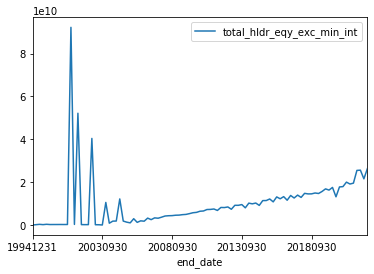

In [21]:
total_equity_history.plot()
plt.show()